# *National Poll on Healthy Aging (NPHA)* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/936/national+poll+on+healthy+aging+(npha))

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

The [*National Poll on Healthy Aging (NPHA)* dataset](https://archive.ics.uci.edu/dataset/936/national+poll+on+healthy+aging+(npha)) provided on the *UCI* repository belongs to the area of health and medicine, containing features related to health and sleep in older American adults.

This is a subset of the original *National Poll on Healthy Aging (NPHA)* dataset, collected to study issues related to health and aging. A few variables were selected to use for a machine learning task aiming to predict the number of doctors a patient visits in a year.

For details about the dataset, the *UCI* webpage points to [the original NPHA study](https://www.icpsr.umich.edu/web/NACDA/studies/37305/versions/V1), on the *National Archive of Computerized Data on Aging (NACDA)*, hosted by the *Inter-university Consortium for Political and Social Research (ICPSR)*, a unit within the *Institute for Social Research* at the *University of Michigan*, USA.

We load the data from the file.

In [2]:
npha_path = "./national+poll+on+healthy+aging+(npha)/NPHA-doctor-visits.csv"
npha_orgdtf = pandas.read_csv(npha_path, sep=",")

We write a function to list the columns that have missing values in a given dataset, or report that there are none, and we apply it to the dataset we just loaded.

In [3]:
def check_missing_values(dtf):
    cols_missing_values = [c for c in dtf if dtf[c].isna().any()]
    if len(cols_missing_values) > 0:
        print("\n\t- ".join(
            ["The following %s columns contain missing values:" % len(cols_missing_values)]+
            cols_missing_values))
    else:
        print("No values are missing.")

check_missing_values(npha_orgdtf)

No values are missing.


We show an outline of the dataset.

In [4]:
npha_orgdtf

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


The dataset contains 714 rows, representing individual patients, and 15 columns, representing features related to health and sleep, as well as the number of doctors visited, which is the prediction target in the original task.

Each attribute contains only integer values. The meaning of the numerical values can be found on the [variables table on the *UCI* webpage](https://archive.ics.uci.edu/dataset/936/national+poll+on+healthy+aging+(npha)).


- **Number of Doctors Visited**: The total count of different doctors the patient has seen
    - **1**: 0&ndash;1 doctors
    - **2**: 2&ndash;3 doctors
    - **3**: 4 or more doctors
- **Age**: The patient's age group
    - **1**: 50&ndash;64 years old
    - **2**: 65&ndash;80 years old
- **Physical Health**: A self-assessment of the patient's physical well-being (Excellent&ndash;Poor)
- **Mental Health**: A self-evaluation of the patient's mental or psychological health (Excellent&ndash;Poor)
- **Dental Health**: A self-assessment of the patient's oral or dental health (Excellent&ndash;Poor)
- **Employment**: The patient's employment status or work-related information
	- **1**: Working full-time
	- **2**: Working part-time
	- **3**: Retired
	- **4**: Not working at this time
- **Stress Keeps Patient from Sleeping**: Whether stress affects the patient's ability to sleep (Yes/No)
- **Medication Keeps Patient from Sleeping**: Whether medication impacts the patient's sleep (Yes/No)
- **Pain Keeps Keeps Patient from Sleeping**: Whether physical pain disturbs the patient's sleep (Yes/No)
- **Bathroom Keeps Patient from Sleeping**: Whether the need to use the bathroom affects the patient's sleep (Yes/No)
- **Unknown Keeps Patient from Sleeping**: Unidentified factors affecting the patient's sleep (Yes/No)
- **Trouble Sleeping**: General issues or difficulties the patient faces with sleeping (Yes/No)
- **Prescription Sleep Medication**: Information about any sleep medication prescribed to the patient
	- **1**: Use regularly
	- **2**: Use occasionally
	- **3**: Do not use
- **Race**: The patient's racial or ethnic background
	- **1**: White, Non-Hispanic
	- **2**: Black, Non-Hispanic
	- **3**: Other, Non-Hispanic
	- **4**: Hispanic
	- **5**: 2+ Races, Non-Hispanic
- **Gender**: The gender identity of the patient
	- **1**: Male
	- **2**: Female

Throughout, values equal to **-1** indicate that the patient refused to answer.

Attributes corresponding to Yes/No questions use the following encoding of the answers:
- **0**: No
- **1**: Yes

Health self-assessment attributes are measured on a five steps scale, from excellent to poor, as follows:
- **1**: Excellent
- **2**: Very Good
- **3**: Good
- **4**: Fair
- **5**: Poor

We obtain a summary of the dataset, considering the attributes as discrete variables to get count statistics rather than distributional statistics.
That is, for each attribute the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the number of distinct values (`unique`), the most frequent value and its number of occurrences (`top` and `freq`, respectively).

In [5]:
npha_orgdtf.astype(object).describe()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
count,714,714,714,714,714,714,714,714,714,714,714,714,714,714,714
unique,3,1,6,6,7,4,2,2,2,2,2,4,4,5,2
top,2,2,3,2,2,3,0,0,0,1,0,3,3,1,2
freq,372,714,291,282,215,592,537,674,558,360,416,359,639,578,393


We note that all values of the `Age` attribute are equal to 2 (corresponding to the age range of 65 to 80 years old), making it useless, so we drop this attribute.
We also note a couple of typos in the names of attributes, which we correct, and we abbreviate the phrase `Keeps Patient from Sleeping` to `KPfS`.

In [6]:
npha_dtf = npha_orgdtf.drop(columns="Age").rename(columns=
                    lambda x: x.replace("Phyiscal", "Physical").replace("Uknown", "Unknown").replace("Keeps Patient from Sleeping", "KPfS"))

Furthermore, we note that while `Trouble Sleeping` is listed as a Yes/No variable in the [variables table on the UCI webpage](https://archive.ics.uci.edu/dataset/936/national+poll+on+healthy+aging+(npha)), the attribute contains four distinct values, namely values -1, 1, 2 and 3. From the [description of variables in the original dataset](https://www.icpsr.umich.edu/web/NACDA/studies/37305/versions/V1/variables?q=trouble), and in particular [variable `PROB_FALLING_ASLEEP`](https://www.icpsr.umich.edu/web/NACDA/studies/37305/datasets/0001/variables/PROB_FALLING_ASLEEP?archive=nacda), it seems probable that the attribute records the frequency at which patients face trouble falling asleep (presumably on a weekly basis), with values 1, 2 and 3 encoding respectively 3&ndash;7 nights, 1&ndash;2 nights, and 0 nights.

Also, while we expect health self-assessment attributes to be measured on a five steps scale, and hence to take six distinct values when including the option representing a refusal to answer, we observe that `Dental Health` actually comes with seven distinct values, including an unexpected value 6, as we will see shortly. As a result, it is not clear how to interpret the values of this attribute.

Next, we draw histograms of the different attributes.
On the first row, we display the attributes recording whether medication, pain, stress, bathroom visits and unknown factors affect patients' ability to sleep.
On the second row, we display the physical, mental and dental health self-evaluation scores, as well as a score recording the level of trouble sleeping and the original target attribute recording the number of doctors visited.
On the last row, we display demographic attributes, recording respectively the gender, race and employment status of the patients, as well the attribute recording the use of prescribed sleep medication.

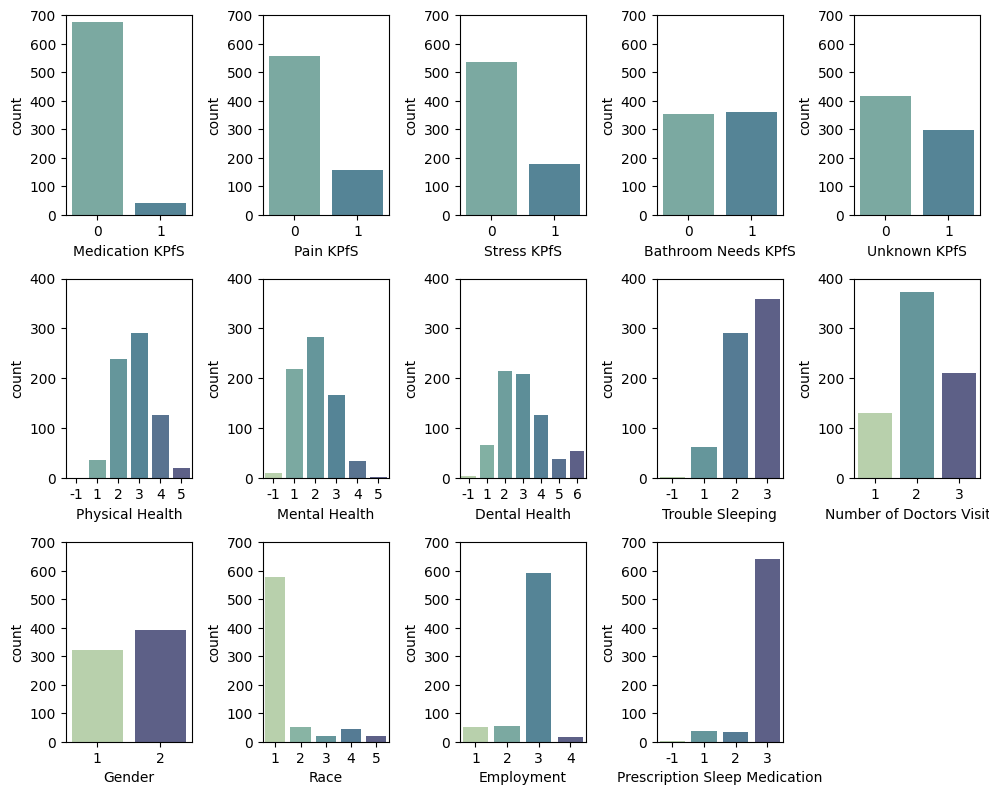

In [7]:
sorted_columns = ["Medication KPfS", "Pain KPfS", "Stress KPfS", "Bathroom Needs KPfS", "Unknown KPfS",
                  "Physical Health", "Mental Health", "Dental Health", "Trouble Sleeping", "Number of Doctors Visited",
                  "Gender", "Race", "Employment", "Prescription Sleep Medication"]
f, axes = plt.subplots(3, 5)
for ci, c in enumerate(sorted_columns):
    seaborn.countplot(data=npha_dtf, x=c, alpha=0.8, legend=None, ax=axes[ci//5, ci%5], hue=c, palette="crest")
    axes[ci//5, ci%5].set_ylim([0,400 if ci//5 ==1 else 700])
axes[-1, -1].axis("off")

f.set_figheight(8)
f.tight_layout()

The need to use the bathroom is the most common factor affecting patients' ability to sleep, with slightly more than half of the patients reporting it. Unsurprisingly considering the age group, most patients are retired (`Employment` value 3). Most patients do not use sleep medication (`Prescription Sleep Medication` value 3).

Next, we compute and display correlations between pairs of attributes, keeping the attributes in the same order as in the previous figure.
We show only the lower triangle of the correlation matrix, which is enough to visualize all the information, since the upper triangle is identical to it under symmetry along the diagonal, and display values as signed percentages.

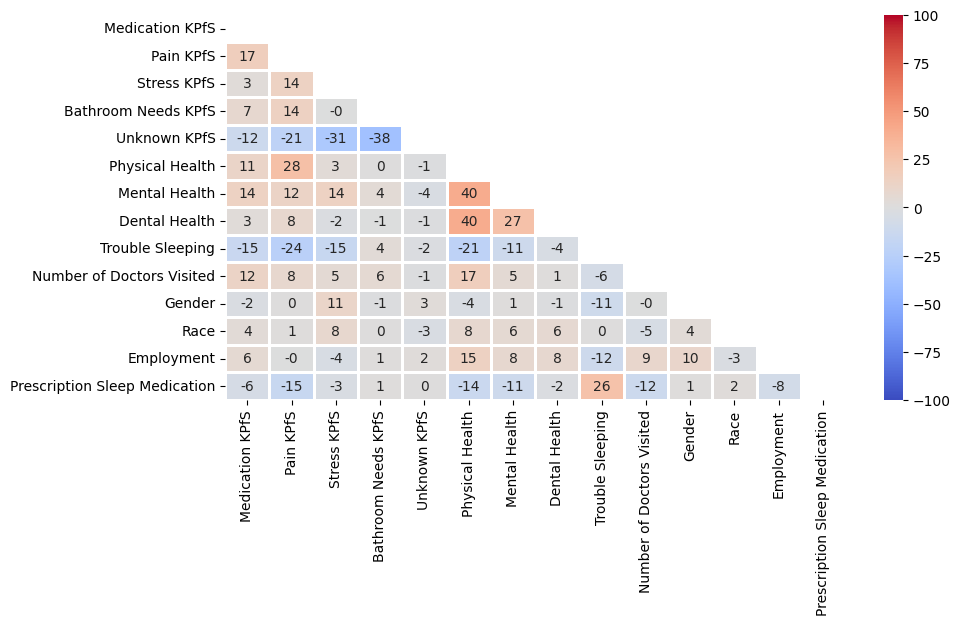

In [8]:
crm = 100*npha_dtf.corr().loc[sorted_columns,sorted_columns]
mask = numpy.triu(numpy.ones_like(crm, dtype=bool))
seaborn.heatmap(crm, linewidth=.8, vmin=-100, vmax=100, mask=mask,
                annot=True, fmt=".0f", cmap="coolwarm");

Whereas known factors keeping patients from sleeping are weakly positively correlated with each other, the attribute representing unknown factors is more strongly negatively correlated with known factors. This seems fairly logical. If a patient declares some known factor as affecting their ability to sleep, they are less likely to also declare unknown factors.

Health self-evaluation scores are positively correlated with each other, meaning that the different aspects of health are not independent.
Finally, the `Trouble Sleeping` attribute is negatively correlated with most factors affecting sleep. That is, lower values for this attribute, representing more frequent troubles, tend to be associated with declaring some factors causing the troubles, especially pain (-24%), followed by medication (-15%) and stress (-15%). On the other hand, there is almost no correlation between the need to use the bathroom as factor affecting sleep and frequent troubles falling asleep (-2%).